<a href="https://colab.research.google.com/github/Levi-003/AI-training-Tasks/blob/main/Deep_Learning_and_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [3]:
from google.colab import files

uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [5]:
df = pd.read_csv("winequality-red.csv", sep=",")

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nQuality Distribution:")
print(df["quality"].value_counts().sort_index())

Shape: (1599, 12)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate Rows:
240

Quality D

In [8]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1359, 12)


In [11]:
df["quality_class"] = pd.cut(
    df["quality"],
    bins=[2, 4, 6, 8],
    labels=[0, 1, 2]
)

df["quality_class"] = df["quality_class"].astype(int)

print(df[["quality", "quality_class"]].head(10))

    quality  quality_class
0         5              1
1         5              1
2         5              1
3         6              1
5         5              1
6         5              1
7         7              2
8         7              2
9         5              1
10        5              1


In [12]:
print(df["quality_class"].value_counts().sort_index())

quality_class
0      63
1    1112
2     184
Name: count, dtype: int64


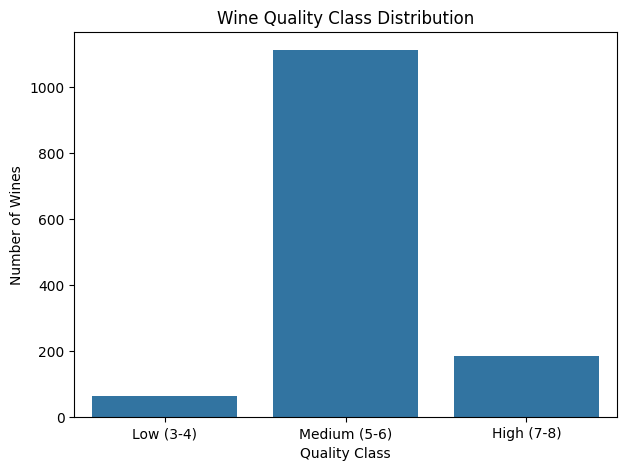

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="quality_class"
)

plt.title("Wine Quality Class Distribution")
plt.xlabel("Quality Class")
plt.ylabel("Number of Wines")
plt.xticks(
    [0, 1, 2],
    ["Low (3-4)", "Medium (5-6)", "High (7-8)"]
)

plt.show()

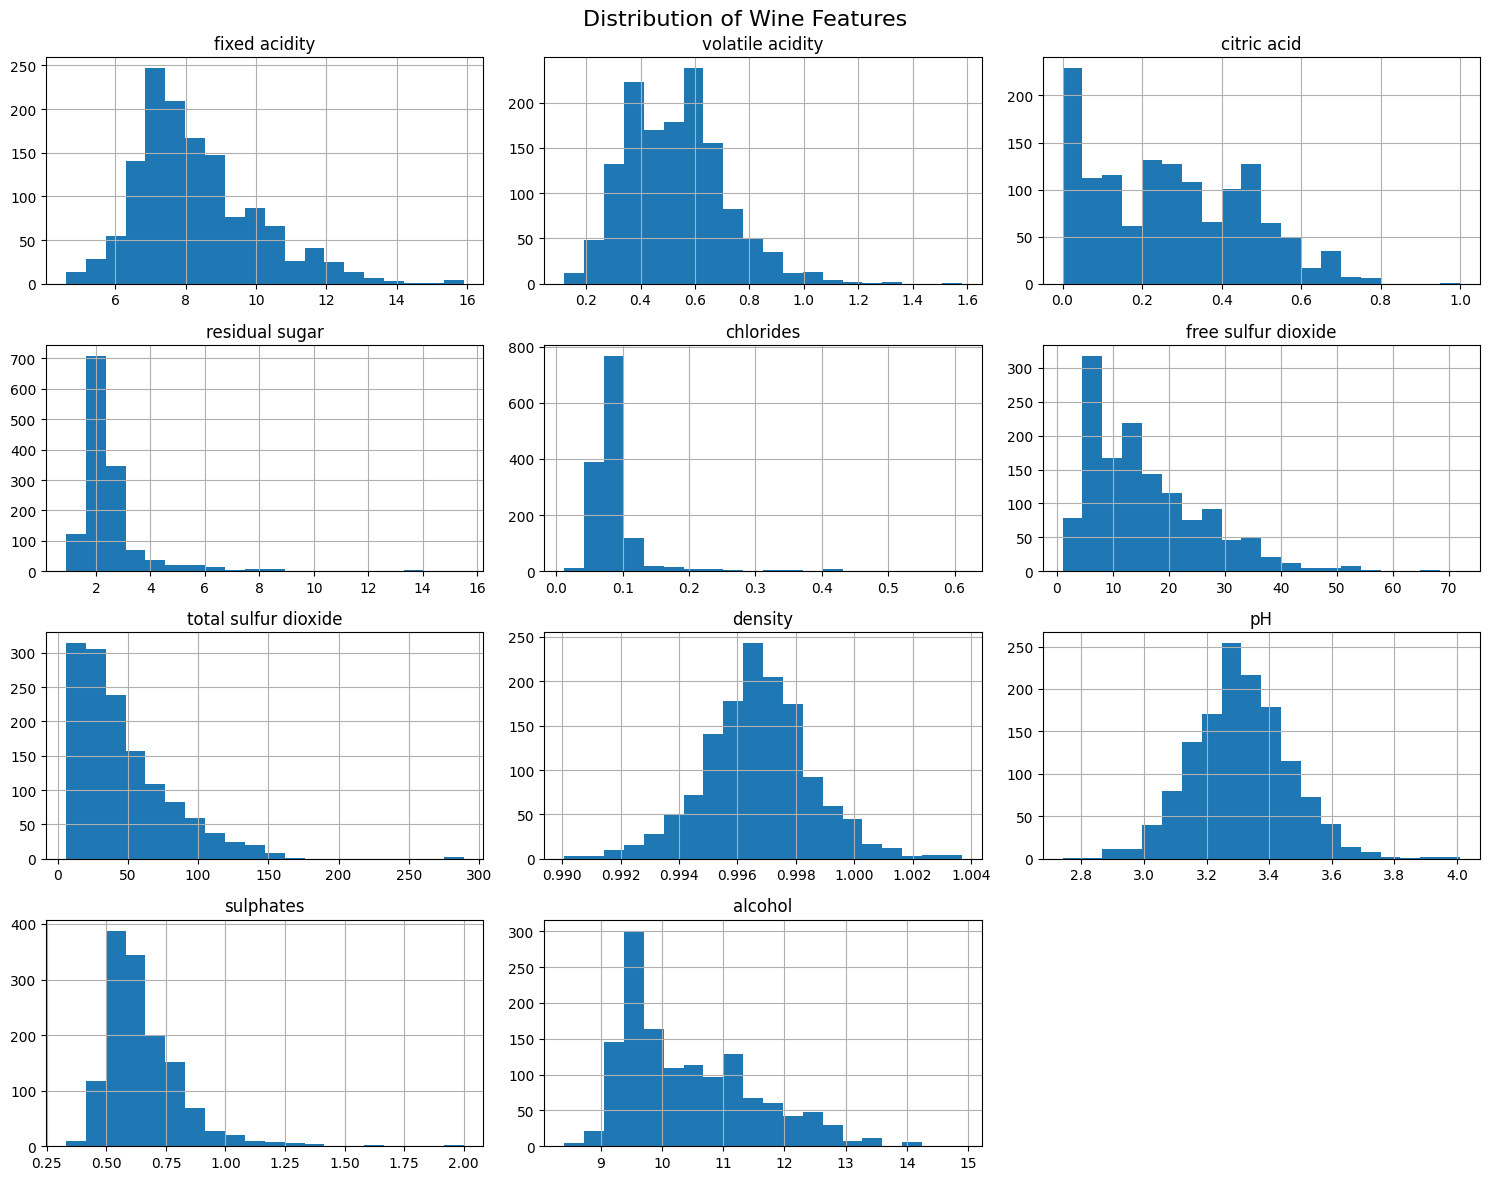

In [14]:
features = df.drop(columns=["quality", "quality_class"])

features.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Wine Features", fontsize=16)
plt.tight_layout()
plt.show()

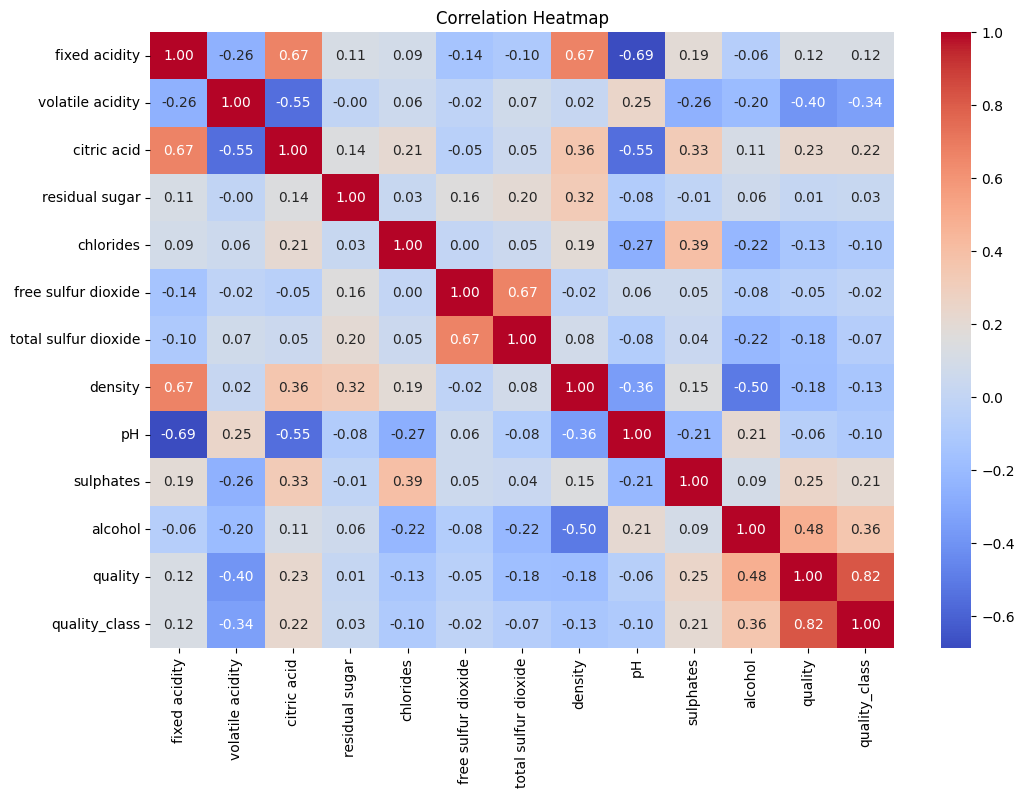

In [15]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

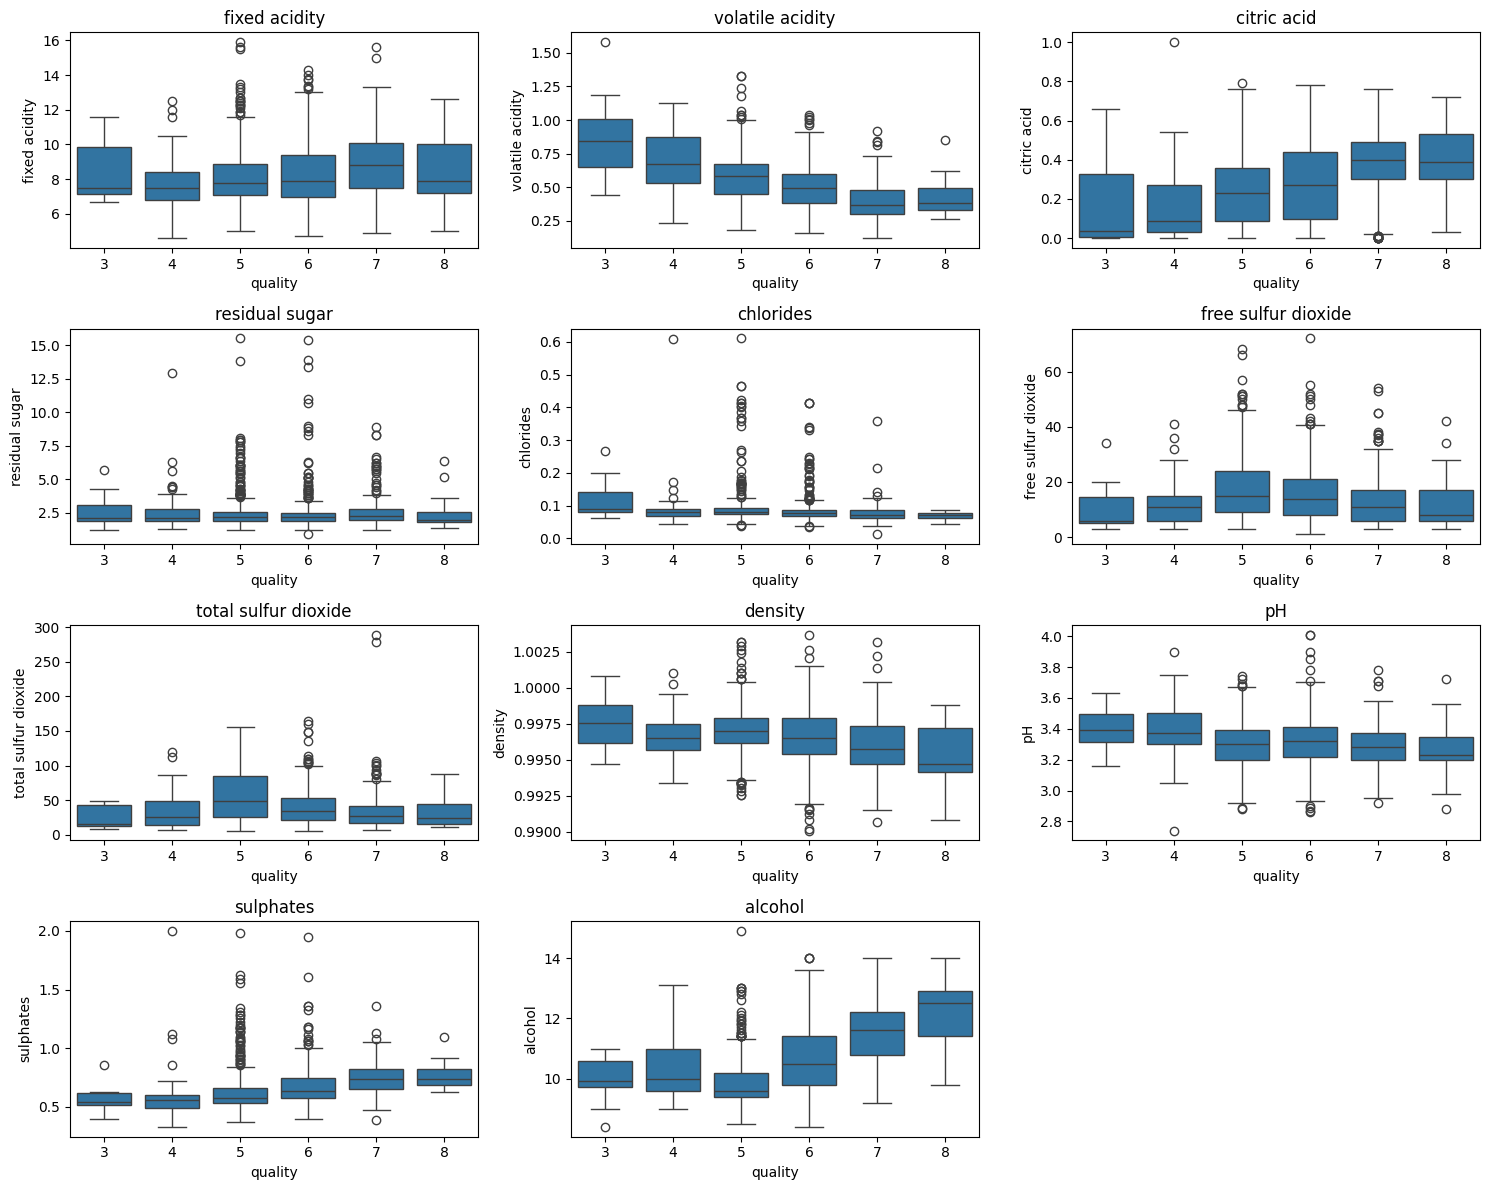

In [16]:
plt.figure(figsize=(15, 12))

for i, column in enumerate(features.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(
        data=df,
        x="quality",
        y=column
    )
    plt.title(column)

plt.tight_layout()
plt.show()

In [18]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1359, 11)
Target shape: (1359,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1087, 11)
Testing data: (272, 11)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
print(X_train_scaled[:5])

Training data after scaling:
[[ 0.19875528  0.77120054 -0.87903384 -0.66208755  0.04918125 -1.12291701
  -1.0655761   0.37217578  0.01078313 -0.04940309 -0.8013678 ]
 [-0.42598628 -0.12386319 -0.62375471  0.20046126  0.48881955  1.60722937
   0.75832667 -0.66285845 -0.89085284 -0.16794868 -0.20730997]
 [-0.70995972 -0.99180377  0.09102685 -0.01517594  0.18107274  0.38337065
   0.16997094 -0.2913077   0.7192114  -0.04940309  0.52383813]
 [-0.53957566 -0.8833112   0.80580842  0.05670313 -0.12667407  0.19508469
   1.02308675  0.17578467  0.13958827  0.1284153  -0.66427753]
 [-0.31239691  2.04598827 -1.03220132 -0.44645035 -0.65424003  0.5716566
  -0.00653578 -0.79555515  1.29883453 -1.3534046   0.24965759]]


In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
print(class_weight_dict)

Class weights:
{np.int64(0): np.float64(7.246666666666667), np.int64(1): np.float64(0.40711610486891386), np.int64(2): np.float64(2.4648526077097506)}


In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),

    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,971 (46.76 KB)

 Trainable params: 11,971 (46.76 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6536 - loss: 0.5392 - val_accuracy: 0.6055 - val_loss: 0.8370
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6444 - loss: 0.5421 - val_accuracy: 0.6055 - val_loss: 0.7946
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6018 - loss: 0.5178 - val_accuracy: 0.5917 - val_loss: 0.8156
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6467 - loss: 0.5295 - val_accuracy: 0.5688 - val_loss: 0.8632
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6295 - loss: 0.5162 - val_accuracy: 0.6101 - val_loss: 0.7944
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6686 - loss: 0.5227 - val_accuracy: 0.6147 - val_loss: 0.7842
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6686 - loss: 0.5057 - val_accuracy: 0.6101 - val_loss: 0.7835
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6295 - loss: 0.5464 - val_accuracy: 0.5596 - v

In [27]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.8015413880348206
Test Accuracy: 0.6875


In [28]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low", "Medium", "High"]
))

              precision    recall  f1-score   support

         Low       0.19      0.46      0.27        13
      Medium       0.92      0.68      0.78       222
        High       0.39      0.78      0.52        37

    accuracy                           0.69       272
   macro avg       0.50      0.64      0.52       272
weighted avg       0.81      0.69      0.72       272



In [30]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.8015413880348206
Test Accuracy: 0.6875


In [31]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions:", y_pred[:20])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Predictions: [1 0 1 1 1 0 2 1 2 0 1 1 2 1 2 1 1 1 2 1]


In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low", "Medium", "High"]
))

              precision    recall  f1-score   support

         Low       0.19      0.46      0.27        13
      Medium       0.92      0.68      0.78       222
        High       0.39      0.78      0.52        37

    accuracy                           0.69       272
   macro avg       0.50      0.64      0.52       272
weighted avg       0.81      0.69      0.72       272



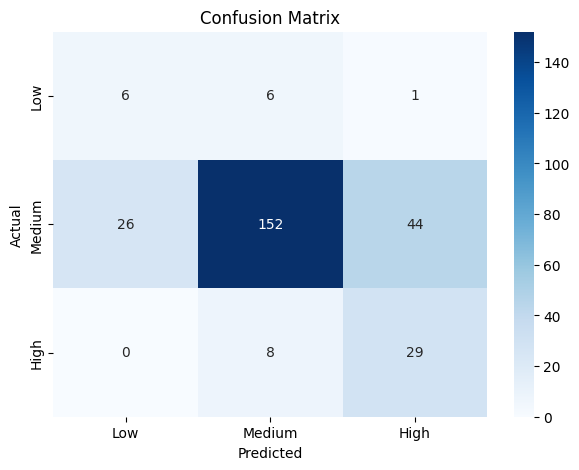

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.6433356433356433


In [36]:
!pip install -q gradio

In [37]:
import numpy as np

def predict_wine(
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol
):
    input_data = np.array([[
        fixed_acidity,
        volatile_acidity,
        citric_acid,
        residual_sugar,
        chlorides,
        free_sulfur_dioxide,
        total_sulfur_dioxide,
        density,
        pH,
        sulphates,
        alcohol
    ]])

    input_scaled = scaler.transform(input_data)

    probabilities = model.predict(input_scaled, verbose=0)[0]

    class_names = ["Low", "Medium", "High"]

    predicted_class = np.argmax(probabilities)
    predicted_label = class_names[predicted_class]

    return {
        "Low": float(probabilities[0]),
        "Medium": float(probabilities[1]),
        "High": float(probabilities[2])
    }

In [39]:
import gradio as gr

demo = gr.Interface(
    fn=predict_wine,
    inputs=[
        gr.Number(label="Fixed Acidity", value=7.4),
        gr.Number(label="Volatile Acidity", value=0.70),
        gr.Number(label="Citric Acid", value=0.00),
        gr.Number(label="Residual Sugar", value=1.9),
        gr.Number(label="Chlorides", value=0.076),
        gr.Number(label="Free Sulfur Dioxide", value=11),
        gr.Number(label="Total Sulfur Dioxide", value=34),
        gr.Number(label="Density", value=0.9978),
        gr.Number(label="pH", value=3.51),
        gr.Number(label="Sulphates", value=0.56),
        gr.Number(label="Alcohol", value=9.4)
    ],
    outputs=gr.Label(num_top_classes=3),
    title="🍷 Red Wine Quality Predictor",
    description="Enter the physicochemical properties of a red wine to predict its quality class."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://285f45e52154a90c36.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
